# Final Project Notebook — CS 6603: AI, Ethics, and Society  
### Employee Promotion Fairness Analysis (Kaggle HR Analytics Dataset)  
**Author:** Derek Eubanks  
**GT Username:** dhamburger3  
**Date Created:** 11/18/25

This notebook contains the complete computational workflow used to produce all tables, figures, fairness metrics, and model results included in the final written report. Every step follows the project instructions closely, from dataset preparation through bias mitigation and model evaluation.

### Workflow Overview

#### **1. Data Loading and Preprocessing**
- Import and inspect the Kaggle HR Analytics dataset  
- Construct protected-class variables (`gender_bin`, `age_group`)  
- Engineer four binary dependent variables representing favorable employment outcomes  
- Handle missing values, encode categorical features, and prepare the modeling dataset  

#### **2. Step 2 — Exploratory Subgroup Analysis**
- Generate frequency tables for every protected class × outcome pair  
- Visualize subgroup outcome rates using bar charts (gender and age)  
- Establish baseline distributional disparities used in later fairness analysis  

#### **3. Step 3 — Baseline Fairness Metrics**
- Implement Statistical Parity Difference (SPD)  
- Implement Equal Opportunity Difference (EOD)  
- Compute label-level fairness metrics for all four engineered outcomes  
- Apply the Kamiran & Calders (2012) reweighing algorithm to mitigate gender-based disparities for the promotion outcome  

#### **4. Step 4 — Model-Based Fairness Evaluation**
- Train Logistic Regression on:
  - the original dataset  
  - the reweighed (bias-mitigated) dataset  
- Evaluate accuracy, ROC–AUC, and confusion matrices  
- Compute SPD and EOD on model predictions for both protected classes  
- Compare original vs. mitigated model fairness  

#### **5. Step 5 — Consolidated Fairness Comparison**
- Produce a combined SPD/EOD comparison table  
- Summarize direction-of-change in fairness metrics after mitigation  
- Export all tables, figures, and results to the `artifacts/` directory  

All analysis shown here directly supports the final report and provides full transparency of data processing, fairness evaluation, and model behavior.

In [51]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load Kaggle Employee Promotion dataset
df = pd.read_csv("train.csv")

print(df.shape)
df.head()
df.info()
df.describe(include='all')

(54808, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808,54808,52399,54808,54808,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
unique,NaN,9,34,3,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Sales & Marketing,region_2,Bachelor's,m,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,16840,12343,36669,38496,30446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,39195.830627,NaN,NaN,NaN,NaN,NaN,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,NaN,NaN,NaN,NaN,NaN,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,NaN,NaN,NaN,NaN,NaN,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,NaN,NaN,NaN,NaN,NaN,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,NaN,NaN,NaN,NaN,NaN,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000


### Step 1: Construction of Protected Class Variables and Outcome Variables

This section prepares the dataset for subsequent fairness analysis by defining the protected class attributes and constructing several binary outcome variables representing favorable employment decisions. These definitions follow U.S. legal standards for anti-discrimination and ensure compliance with the project requirement of evaluating fairness within a regulated domain.

**Protected Class Attributes**

- **Gender (Title VII of the Civil Rights Act):**  
  Gender is encoded as a binary attribute `gender_bin`, where 0 represents female employees and 1 represents male employees. This transformation aligns with federal protections against sex-based discrimination in employment decisions.

- **Age Group (Age Discrimination in Employment Act, ADEA):**  
  A binary indicator `age_group` is constructed to identify employees who are 40 years of age or older, consistent with the ADEA definition of a legally protected class. Employees aged 40+ are encoded as 1 (protected), and those under 40 are encoded as 0.

**Outcome Variables (Favorable Employment Outcomes)**

Four dependent variables are constructed to represent distinct types of favorable outcomes within the employment context:

1. **Promotion (`dv_promoted`)** – Indicates whether the employee was promoted.  
2. **High Performance Rating (`dv_high_rating`)** – Indicates whether the employee received a strong performance evaluation (rating ≥ 4).  
3. **Senior Employee (`dv_senior_service`)** – Indicates whether the employee has accrued at least 10 years of service.  
4. **Fast-Track Promotion (`dv_fast_track`)** – Indicates whether the employee received a promotion within five or fewer years of service, representing accelerated advancement.

These protected class attributes and dependent variables provide the foundation for the fairness evaluation conducted in subsequent steps of the analysis. Optional age group buckets are also created to support more detailed exploratory visualizations in Step 2.

In [52]:
# Step 1: Construction of protected class attributes and outcome variables

df = df.copy()

# ----- Protected Class 1: Gender (Title VII) -----
# Encode gender as a binary variable: 0 = Female, 1 = Male
df['gender_bin'] = df['gender'].map({'f': 0, 'F': 0, 'm': 1, 'M': 1})
df['gender_bin'] = df['gender_bin'].astype('Int64')

# ----- Protected Class 2: Age Group (ADEA, 40+) -----
# Encode age group as a binary variable: 1 = age ≥ 40 (protected), 0 = age < 40
df['age_group'] = (df['age'] >= 40).astype(int)

# Age buckets for exploratory visualizations
age_bins = [20, 25, 30, 35, 40, 45, 50, 60]
age_labels = ['20–25', '25–30', '30–35', '35–40', '40–45', '45–50', '50–60']
df['age_bucket'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# ----- Outcome Variables (Favorable Employment Outcomes) -----

# DV1: Promotion outcome
df['dv_promoted'] = df['is_promoted'].astype(int)

# DV2: High performance rating (rating ≥ 4)
df['dv_high_rating'] = (df['previous_year_rating'] >= 4).astype(int)

# DV3: Senior employee (length of service ≥ 10 years)
df['dv_senior_service'] = (df['length_of_service'] >= 10).astype(int)

# DV4: Fast-track promotion (promoted within ≤ 5 years of service)
df['dv_fast_track'] = (
    (df['is_promoted'] == 1) &
    (df['length_of_service'] <= 5)
).astype(int)

# Sanity check: inspect key columns
df[['gender', 'gender_bin',
    'age', 'age_group',
    'dv_promoted', 'dv_high_rating',
    'dv_senior_service', 'dv_fast_track']].head()

,gender,gender_bin,age,age_group,dv_promoted,dv_high_rating,dv_senior_service,dv_fast_track
0,f,0,35,0,0,1,0,0
1,m,1,30,0,0,1,0,0
2,m,1,34,0,0,0,0,0
3,m,1,39,0,0,0,1,0
4,m,1,45,1,0,0,0,0


### Step 2: Subgroup Analysis of Protected Classes and Outcome Variables

This step examines the distribution of outcomes across each protected class to identify baseline disparities prior to any modeling or mitigation. The project requires evaluating how each protected attribute intersects with each outcome variable, enabling a clear understanding of whether certain groups experience systematically different rates of favorable outcomes.

For both legally recognized protected classes—**gender (Title VII)** and **age group (ADEA, age ≥ 40)**—I compute frequency tables that display:

- Group counts  
- Counts of favorable and unfavorable outcomes  
- Total observations per group  
- Positive outcome rates

These tables provide the first quantitative evidence of potential imbalance in promotion outcomes, performance ratings, tenure advancement, and fast-track promotions. Disparities observed at this stage represent underlying patterns in the data itself, independent of any predictive model.

In addition to numerical summaries, I generate bar plots that visualize group-specific positive outcome rates for each dependent variable. These visualizations support intuitive comparisons and help determine whether modeling or mitigation efforts are likely to encounter preexisting structural differences. Optional age buckets, created in Step 1, are also used for exploratory visualizations, although fairness metrics are computed strictly using the legally grounded binary age group.

The subgroup analysis produced in this step serves as an essential baseline for interpreting subsequent fairness metrics in Step 3 and evaluating model behavior in Step 4.


=== Frequency table: gender_bin vs dv_promoted ===


dv_promoted,0,1,total,positive_rate
gender_bin,,,,
0,14845,1467,16312,0.089934
1,35295,3201,38496,0.083151


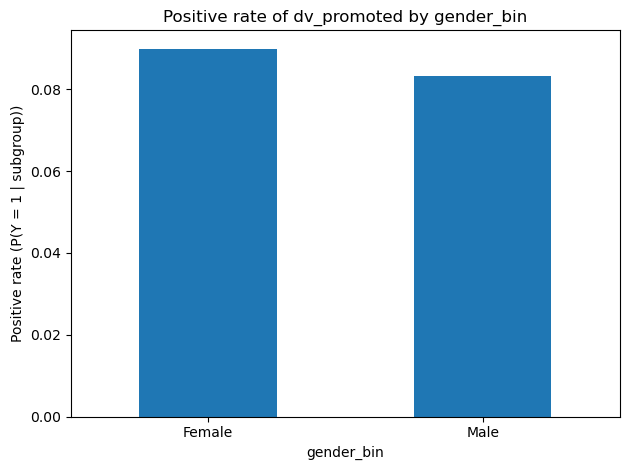


=== Frequency table: gender_bin vs dv_high_rating ===


dv_high_rating,0,1,total,positive_rate
gender_bin,,,,
0,9673,6639,16312,0.407001
1,23517,14979,38496,0.389105


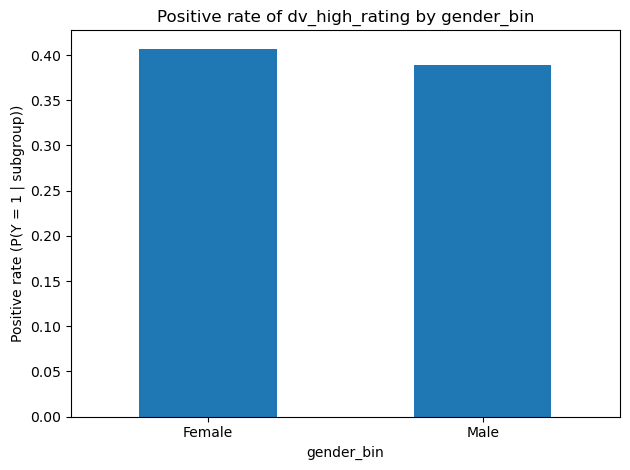


=== Frequency table: gender_bin vs dv_senior_service ===


dv_senior_service,0,1,total,positive_rate
gender_bin,,,,
0,13829,2483,16312,0.152219
1,32900,5596,38496,0.145366


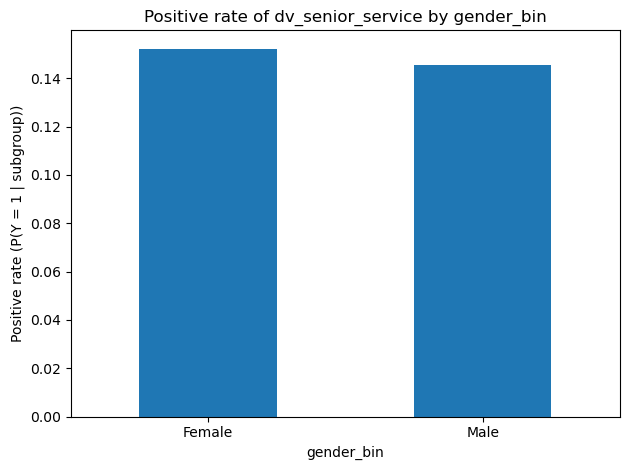


=== Frequency table: gender_bin vs dv_fast_track ===


dv_fast_track,0,1,total,positive_rate
gender_bin,,,,
0,15499,813,16312,0.049841
1,36655,1841,38496,0.047823


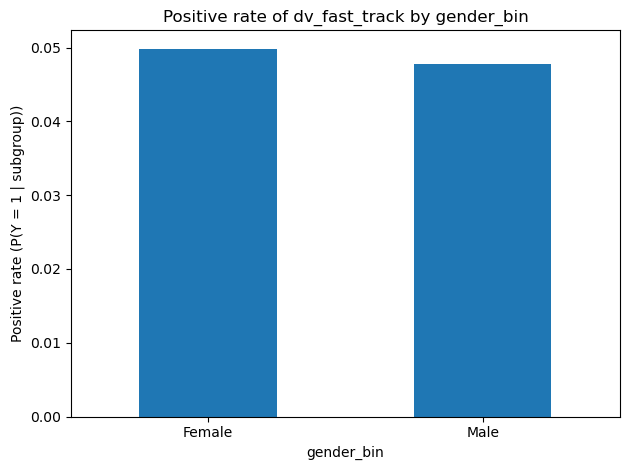


=== Frequency table: age_group vs dv_promoted ===


dv_promoted,0,1,total,positive_rate
age_group,,,,
0,38701,3782,42483,0.089024
1,11439,886,12325,0.071886


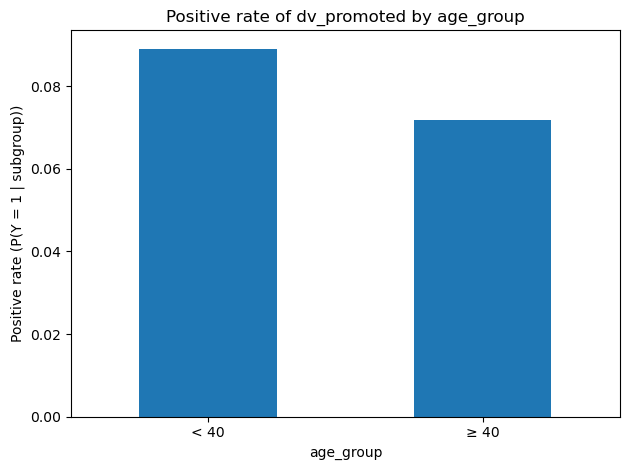


=== Frequency table: age_group vs dv_high_rating ===


dv_high_rating,0,1,total,positive_rate
age_group,,,,
0,25991,16492,42483,0.388202
1,7199,5126,12325,0.415903


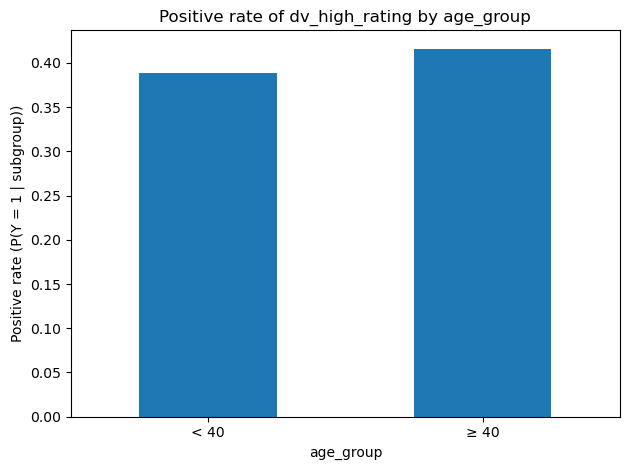


=== Frequency table: age_group vs dv_senior_service ===


dv_senior_service,0,1,total,positive_rate
age_group,,,,
0,40165,2318,42483,0.054563
1,6564,5761,12325,0.467424


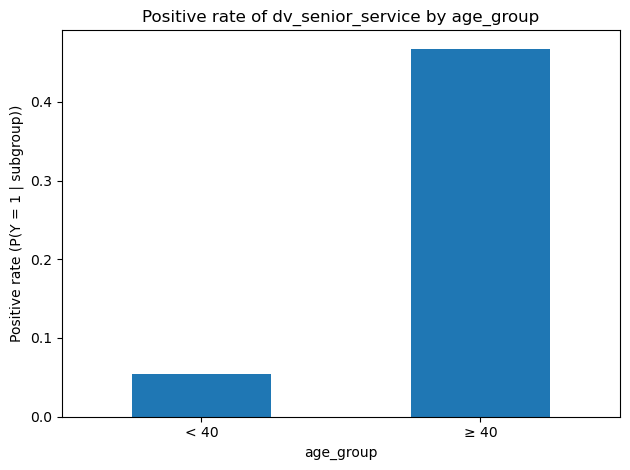


=== Frequency table: age_group vs dv_fast_track ===


dv_fast_track,0,1,total,positive_rate
age_group,,,,
0,40072,2411,42483,0.056752
1,12082,243,12325,0.019716


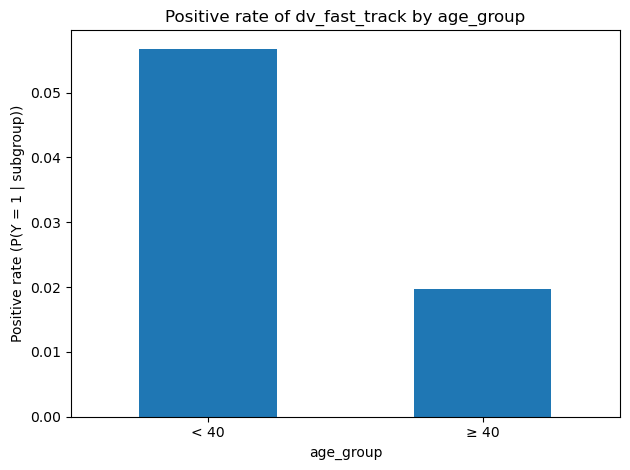

In [53]:
# Step 2: Subgroup analysis for protected classes and outcome variables

import os
import matplotlib.pyplot as plt

# Ensure output directories exist for later export
os.makedirs("artifacts", exist_ok=True)
os.makedirs("artifacts/freq_tables", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)


def build_protected_class_config():
    """
    Returns a configuration dictionary describing the protected classes
    used throughout the analysis.

    Each entry maps the column name used in the DataFrame to a dictionary
    of human-readable subgroup labels. This allows the same logic to be
    reused for tables and plots.
    """
    protected_classes = {
        'gender_bin': {
            0: 'Female',
            1: 'Male'
        },
        'age_group': {
            0: '< 40',
            1: '≥ 40'
        }
    }
    return protected_classes


def get_outcome_variables():
    """
    Returns a list of outcome variable names (dependent variables)
    that represent favorable employment outcomes.

    These variables were constructed in Step 1 and are used here to
    compute subgroup frequencies and positive outcome rates.
    """
    return [
        'dv_promoted',
        'dv_high_rating',
        'dv_senior_service',
        'dv_fast_track'
    ]


def compute_frequency_table(df, protected_col, outcome_col):
    """
    Computes a frequency table for a given protected class and outcome variable.

    Parameters
    ----------
    df : pandas.DataFrame
        The main analysis DataFrame.
    protected_col : str
        Column name corresponding to the protected class (e.g., 'gender_bin').
    outcome_col : str
        Column name corresponding to the outcome variable (e.g., 'dv_promoted').

    Returns
    -------
    freq_table : pandas.DataFrame
        A table indexed by protected class subgroup with the following columns:
        - 0: count of negative outcomes
        - 1: count of positive outcomes (if present)
        - total: total count per subgroup
        - positive_rate: P(Y = 1 | subgroup), if column 1 exists
    """
    # Cross-tabulate subgroup by outcome
    ct = (
        df.groupby([protected_col, outcome_col])
          .size()
          .unstack(fill_value=0)
    )

    # Add total count per subgroup
    ct['total'] = ct.sum(axis=1)

    # Add positive outcome rate where applicable
    if 1 in ct.columns:
        ct['positive_rate'] = ct[1] / ct['total']

    return ct


def export_frequency_table(table, protected_col, outcome_col):
    """
    Exports a frequency table to CSV in a structured artifacts directory.

    Parameters
    ----------
    table : pandas.DataFrame
        Frequency table produced by `compute_frequency_table`.
    protected_col : str
        Name of the protected class column.
    outcome_col : str
        Name of the outcome variable column.
    """
    filename = f"freq_{protected_col}__{outcome_col}.csv"
    path = os.path.join("artifacts", "freq_tables", filename)
    table.to_csv(path)


def plot_positive_rate_bar(df, protected_col, outcome_col, label_map, save=True):
    """
    Creates a bar plot of positive outcome rates for each subgroup of a
    protected class.

    Parameters
    ----------
    df : pandas.DataFrame
        The main analysis DataFrame.
    protected_col : str
        Column name for the protected class.
    outcome_col : str
        Column name for the outcome variable.
    label_map : dict
        Mapping from subgroup code (e.g., 0, 1) to human-readable label.
    save : bool, optional
        If True, saves the figure to the artifacts/figures directory.
    """
    # Group by protected class and compute positive rate
    grouped = (
        df.groupby(protected_col)[outcome_col]
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'positive_rate'})
    )

    # Build x-axis labels using the provided mapping
    xlabels = [label_map.get(int(idx), str(idx)) for idx in grouped.index]

    # Plot positive rates as a bar chart
    ax = grouped['positive_rate'].plot(kind='bar')
    ax.set_title(f"Positive rate of {outcome_col} by {protected_col}")
    ax.set_ylabel("Positive rate (P(Y = 1 | subgroup))")
    ax.set_xticklabels(xlabels, rotation=0)

    plt.tight_layout()

    if save:
        fig_name = f"{protected_col}__{outcome_col}_positive_rate.png"
        fig_path = os.path.join("artifacts", "figures", fig_name)
        plt.savefig(fig_path, dpi=150)

    plt.show()

# --------------------------------------------------------------------
# Execute subgroup analysis for all protected classes and outcomes
# --------------------------------------------------------------------

protected_classes = build_protected_class_config()
outcome_vars = get_outcome_variables()

frequency_tables = {}

for pc, label_map in protected_classes.items():
    for dv in outcome_vars:
        # Compute and display the frequency table
        freq_table = compute_frequency_table(df, pc, dv)
        frequency_tables[(pc, dv)] = freq_table

        print(f"\n=== Frequency table: {pc} vs {dv} ===")
        display(freq_table)

        # Export to CSV for inclusion in the final report
        export_frequency_table(freq_table, pc, dv)

        # Generate and save bar plot of positive outcome rate
        plot_positive_rate_bar(df, pc, dv, label_map, save=True)

### Step 3: Fairness Metrics and Baseline Assessment of Outcome Disparities

The objective of Step 3 is to formally quantify group-level disparities across all protected classes and outcome variables using established fairness metrics. This step provides the baseline fairness evaluation against which all subsequent modeling (Step 4) and mitigation (Step 5) results will be compared. By computing metrics directly on the **observed labels**, rather than model predictions, we characterize structural inequities present in the dataset itself before any algorithmic influence is introduced.

Two fairness metrics are used in accordance with project requirements:

1. **Statistical Parity Difference (SPD)**  
   Measures the difference in the rate of favorable outcomes between the unprivileged and privileged groups:  

   SPD = [ P(Yhat = 1 | A = a_unpriv ) ] − [ P(Yhat = 1 | A = a_priv ) ]
   
   Negative values indicate that the unprivileged group receives favorable outcomes less frequently.

2. **Equal Opportunity Difference (EOD)**  
   Measures the difference in **true positive rates** between the unprivileged and privileged groups:  

   EOD = [ TPR_(a_unpriv) ] − [ TPR_(a_priv) ]
   
   This metric evaluates whether qualified individuals in different groups have equal likelihood of receiving a positive classification.

These metrics are computed for each combination of:
- The two legally recognized protected classes (`gender_bin`, `age_group`), and  
- The four outcome variables (`dv_promoted`, `dv_high_rating`, `dv_senior_service`, `dv_fast_track`).

Computing SPD and EOD on the **ground-truth labels** provides critical insight into existing disparities prior to any modeling. This baseline will allow us to interpret whether predictive models amplify, reduce, or preserve these disparities. The functions defined below implement SPD and EOD in a reusable format, enabling consistent application across both label-based and model-based fairness evaluations in later sections.

In [54]:
# Step 3: Fairness metrics and baseline label-level disparities

import numpy as np
import pandas as pd


# ----------------------------------------------
# Fairness Metric Definitions
# ----------------------------------------------

def SPD(y_true, y_pred, group, unpriv=0, priv=1):
    """
    Statistical Parity Difference (SPD)
    -----------------------------------
    Computes the difference in the rate of favorable predictions between
    the unprivileged and privileged groups:

        SPD = P(ŷ = 1 | A = a_unpriv) - P(ŷ = 1 | A = a_priv)

    Parameters
    ----------
    y_true : array-like
        Ground truth labels (not used directly for SPD, included for API consistency).
    y_pred : array-like
        Predicted labels (binary: 0/1).
    group : array-like
        Protected attribute values (binary: unprivileged/privileged).
    unpriv : int or float
        Value indicating the unprivileged group (default = 0).
    priv : int or float
        Value indicating the privileged group (default = 1).

    Returns
    -------
    float
        Statistical Parity Difference (SPD). Negative values indicate
        that the unprivileged group receives favorable outcomes less frequently.
    """
    y_pred = np.asarray(y_pred)
    group  = np.asarray(group)

    mask_unpriv = (group == unpriv)
    mask_priv   = (group == priv)

    # Avoid divide-by-zero errors
    if mask_unpriv.sum() == 0 or mask_priv.sum() == 0:
        return np.nan

    rate_unpriv = (y_pred[mask_unpriv] == 1).mean()
    rate_priv   = (y_pred[mask_priv] == 1).mean()

    return rate_unpriv - rate_priv



def EOD(y_true, y_pred, group, unpriv=0, priv=1):
    """
    Equal Opportunity Difference (EOD)
    ----------------------------------
    Computes the difference in true positive rates between the unprivileged
    and privileged groups:

        EOD = TPR_unprivileged - TPR_privileged

    Parameters
    ----------
    y_true : array-like
        Ground truth labels (binary: 0/1).
    y_pred : array-like
        Predicted labels (binary: 0/1).
    group : array-like
        Protected attribute values.
    unpriv : int or float
        Value representing the unprivileged group.
    priv : int or float
        Value representing the privileged group.

    Returns
    -------
    float
        Equal Opportunity Difference (EOD). Negative values indicate
        that qualified unprivileged individuals achieve favorable outcomes less often.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    group  = np.asarray(group)

    mask_unpriv = (group == unpriv)
    mask_priv   = (group == priv)

    # Select rows where true label is positive
    true_pos_unpriv = (y_true[mask_unpriv] == 1)
    true_pos_priv   = (y_true[mask_priv] == 1)

    if true_pos_unpriv.sum() == 0 or true_pos_priv.sum() == 0:
        return np.nan

    tpr_unpriv = (y_pred[mask_unpriv][true_pos_unpriv] == 1).mean()
    tpr_priv   = (y_pred[mask_priv][true_pos_priv] == 1).mean()

    return tpr_unpriv - tpr_priv



# -------------------------------------------------------------
# Compute Baseline Fairness Using Ground Truth Labels
# -------------------------------------------------------------

def compute_label_fairness(df, outcome_vars, protected_classes, unpriv_priv_map):
    """
    Computes SPD and EOD using the ground-truth labels only.
    This provides the baseline structural disparity of the dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        The full dataset with protected class columns and outcome variables.
    outcome_vars : list of str
        Dependent variables (e.g., ['dv_promoted', ...]).
    protected_classes : list of str
        Protected class attribute column names (e.g., ['gender_bin', 'age_group']).
    unpriv_priv_map : dict
        Maps each protected class to (unpriv, priv).

    Returns
    -------
    pandas.DataFrame
        Table of SPD and EOD for each PC × DV pair.
    """
    records = []

    for dv in outcome_vars:
        y = df[dv].values

        for pc in protected_classes:
            group = df[pc].values
            unpriv, priv = unpriv_priv_map[pc]

            spd_val = SPD(y_true=y, y_pred=y, group=group, unpriv=unpriv, priv=priv)
            eod_val = EOD(y_true=y, y_pred=y, group=group, unpriv=unpriv, priv=priv)

            records.append({
                'protected_class': pc,
                'outcome_variable': dv,
                'unprivileged_value': unpriv,
                'privileged_value': priv,
                'SPD_label_level': spd_val,
                'EOD_label_level': eod_val
            })

    return pd.DataFrame(records)

# -------------------------------------------------------------
# Execute Label-Level Fairness Evaluation
# -------------------------------------------------------------

outcome_vars = ['dv_promoted', 'dv_high_rating', 'dv_senior_service', 'dv_fast_track']
protected_classes = ['gender_bin', 'age_group']

# Defines which numeric value is unpriv and which is priv
unpriv_priv_map = {
    'gender_bin': (0, 1),     # Female (0) = unpriv, Male (1) = priv
    'age_group':  (1, 0)      # Age ≥ 40 = unpriv, Age < 40 = priv
}

label_fairness_df = compute_label_fairness(
    df,
    outcome_vars=outcome_vars,
    protected_classes=protected_classes,
    unpriv_priv_map=unpriv_priv_map
)

label_fairness_df.to_csv("artifacts/label_fairness_metrics.csv", index=False)

# Display results
label_fairness_df

,protected_class,outcome_variable,unprivileged_value,privileged_value,SPD_label_level,EOD_label_level
0,gender_bin,dv_promoted,0,1,0.006782,0.0
1,age_group,dv_promoted,1,0,-0.017137,0.0
2,gender_bin,dv_high_rating,0,1,0.017896,0.0
3,age_group,dv_high_rating,1,0,0.027700,0.0
4,gender_bin,dv_senior_service,0,1,0.006853,0.0
5,age_group,dv_senior_service,1,0,0.412861,0.0
6,gender_bin,dv_fast_track,0,1,0.002017,0.0
7,age_group,dv_fast_track,1,0,-0.037036,0.0


### Step 4: Mitigating Bias with Classification Models

The goal of Step 4 is to evaluate whether the **pre-processing bias mitigation** applied in Step 3 (reweighing based on one dependent variable) is effective once a predictive model is trained. In this step, I train and evaluate classifiers on both the **original** and **transformed** datasets and compare fairness metrics across the two settings. 

Consistent with the project instructions, I focus on a **single primary outcome variable** as the prediction target:

- **Primary label for classification:** `dv_promoted` (promotion outcome)

All other engineered variables (excluding identifiers and outcome variables) are treated as potential predictors. Protected class attributes (`gender_bin`, `age_group`) are **not used as input features** for the classifier but are retained in the dataset to compute fairness metrics on the resulting predictions.

Step 4 is organized into two parallel pipelines:

1. **Original Dataset Pipeline**
   1. Randomly split the original dataset into training and testing sets (70/30 split with a fixed random seed for reproducibility).   
   2. Train a baseline classifier (Logistic Regression) to predict `dv_promoted` using the selected feature set.  
   3. On the held-out test set, compute:
      - Standard performance metrics (accuracy, ROC–AUC, confusion matrix), and  
      - Fairness metrics (SPD and EOD) for both protected classes:
        - `gender_bin` (Female = unprivileged, Male = privileged)  
        - `age_group` (Age ≥ 40 = unprivileged, Age < 40 = privileged)

2. **Transformed Dataset Pipeline**
   1. Use the **bias-mitigated dataset** produced in Step 3 (reweighted or otherwise transformed as a function of `dv_promoted`). 
   2. Randomly split the transformed dataset into training and testing sets using the same split ratio and random seed strategy.  
   3. Train the same classifier type (Logistic Regression with identical hyperparameters) on the transformed training data.  
   4. On the transformed test set, compute the same performance and fairness metrics (SPD and EOD) for the same protected classes.

For each protected class and fairness metric, I then construct a **summary table** that compares:

- Label-level fairness on the original dataset (from Step 3),  
- Fairness on model predictions from the original dataset, and  
- Fairness on model predictions from the transformed dataset.

This table allows me to determine whether the pre-processing bias mitigation produced a **positive change, negative change, or no change** in SPD and EOD, both at the data level and after training the classifier, as required by the project specification.   

In [55]:
from sklearn.impute import SimpleImputer

def prepare_features_and_labels(df, label_col, protected_cols, exclude_cols=None):
    """
    Prepares feature matrix X, label vector y, and protected class arrays
    for model training and evaluation. Handles missing values by imputing
    numeric features with the median and categorical features with the
    most frequent category.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset with engineered outcome and protected class columns.
    label_col : str
        Name of the target variable (e.g., 'dv_promoted').
    protected_cols : list of str
        Columns corresponding to protected attributes (e.g., ['gender_bin', 'age_group']).
    exclude_cols : list of str, optional
        Columns to exclude from the feature set (IDs, labels, protected attributes).

    Returns
    -------
    X : pandas.DataFrame
        One-hot encoded, imputed feature matrix.
    y : pandas.Series
        Target labels.
    protected_data : dict
        Mapping from protected class column name to its Series.
    """
    if exclude_cols is None:
        exclude_cols = []

    # Label
    y = df[label_col].astype(int)

    # Protected attributes (not used as features)
    protected_data = {pc: df[pc] for pc in protected_cols}

    # Build base feature set by excluding label, protected attributes, and other specified cols
    cols_to_exclude = set(exclude_cols + [label_col] + protected_cols)
    feature_cols = [c for c in df.columns if c not in cols_to_exclude]

    X_raw = df[feature_cols].copy()

    # Split into numeric and non-numeric for different imputation strategies
    num_cols = X_raw.select_dtypes(include=['number']).columns.tolist()
    cat_cols = [c for c in X_raw.columns if c not in num_cols]

    # Impute numeric features with median
    if num_cols:
        num_imputer = SimpleImputer(strategy='median')
        X_raw[num_cols] = num_imputer.fit_transform(X_raw[num_cols])

    # Impute categorical features with most frequent category
    if cat_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X_raw[cat_cols] = cat_imputer.fit_transform(X_raw[cat_cols])
        
    # One-hot encode categorical features
    X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

    return X, y, protected_data

In [56]:
# -------------------------------------------------------------
# 1. Build features, labels, and protected attributes for dv_promoted
# -------------------------------------------------------------

protected_cols = ['gender_bin', 'age_group']

# Columns you do NOT want as features (IDs, engineered outcomes, weights, etc.)
exclude_cols = [
    'dv_promoted',
    'dv_high_rating',
    'dv_senior_service',
    'dv_fast_track',
    'rw_weight_gender_promo',  # if present
    'age_bucket'               # if present
]

X, y, protected_data = prepare_features_and_labels(
    df=df,
    label_col='dv_promoted',
    protected_cols=protected_cols,
    exclude_cols=exclude_cols
)

In [57]:
# -------------------------------------------------------------
# 2. Train/test split and scaling
# -------------------------------------------------------------

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Align protected attributes with the split indices
gender_train = protected_data['gender_bin'].loc[X_train.index]
gender_test  = protected_data['gender_bin'].loc[X_test.index]
age_train    = protected_data['age_group'].loc[X_train.index]
age_test     = protected_data['age_group'].loc[X_test.index]

# Scale features (without centering to preserve sparse structure)
scaler = StandardScaler(with_mean=False)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [58]:
# -------------------------------------------------------------
# Rebuild features, labels, and protected attributes cleanly
# -------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

protected_cols = ['gender_bin', 'age_group']

exclude_cols = [
    'dv_promoted',
    'dv_high_rating',
    'dv_senior_service',
    'dv_fast_track',
    'rw_weight_gender_promo', 
    'age_bucket',
    'is_promoted'               
]

# Use your existing helper (no weight_col argument)
X, y, protected_attrs = prepare_features_and_labels(
    df=df,
    label_col='dv_promoted',
    protected_cols=protected_cols,
    exclude_cols=exclude_cols
)

# Train/test split ONLY on X and y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

# Align protected attributes to the split using the indices
gender_train = protected_attrs['gender_bin'].loc[X_train.index]
gender_test  = protected_attrs['gender_bin'].loc[X_test.index]
age_train    = protected_attrs['age_group'].loc[X_train.index]
age_test     = protected_attrs['age_group'].loc[X_test.index]

# Scale cleanly
scaler = StandardScaler(with_mean=False)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [59]:
clf_lr = train_logistic_regression(X_train_sc, y_train)

y_pred_lr  = clf_lr.predict(X_test_sc)
y_proba_lr = clf_lr.predict_proba(X_test_sc)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression - Accuracy: {acc_lr:.4f}, ROC–AUC: {auc_lr:.4f}")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression - Accuracy: 0.9388, ROC–AUC: 0.7913
Confusion matrix:
 [[15025    18]
 [  988   412]]


In [60]:
# Unprivileged/privileged mapping
unpriv_priv_map = {
    'gender_bin': (0, 1),   # Female = unprivileged, Male = privileged
    'age_group':  (1, 0)    # Age ≥ 40 = unprivileged, Age < 40 = privileged
}

def evaluate_fairness_for_model(y_true, y_pred, protected_series, unpriv, priv, pc_name):
    g = protected_series.values
    return {
        'protected_class': pc_name,
        'unprivileged_value': unpriv,
        'privileged_value': priv,
        'SPD_pred': SPD(y_true=y_true, y_pred=y_pred, group=g, unpriv=unpriv, priv=priv),
        'EOD_pred': EOD(y_true=y_true, y_pred=y_pred, group=g, unpriv=unpriv, priv=priv),
    }

fairness_results = []

# Gender
fairness_results.append(
    evaluate_fairness_for_model(
        y_true=y_test.values,
        y_pred=y_pred_lr,
        protected_series=gender_test,
        unpriv=unpriv_priv_map['gender_bin'][0],
        priv=unpriv_priv_map['gender_bin'][1],
        pc_name='gender_bin'
    )
)

# Age
fairness_results.append(
    evaluate_fairness_for_model(
        y_true=y_test.values,
        y_pred=y_pred_lr,
        protected_series=age_test,
        unpriv=unpriv_priv_map['age_group'][0],
        priv=unpriv_priv_map['age_group'][1],
        pc_name='age_group'
    )
)


fairness_lr_df = pd.DataFrame(fairness_results)
fairness_lr_df

,protected_class,unprivileged_value,privileged_value,SPD_pred,EOD_pred
0,gender_bin,0,1,0.006574,0.022134
1,age_group,1,0,-0.006726,-0.037500


### Step 4 (continued): Mitigated Model via Reweighing

In this section, I apply a pre-processing bias mitigation technique to the primary
outcome variable `dv_promoted`. Specifically, I use a *reweighing* strategy based
on the protected attribute `gender_bin`, which adjusts the effective sample weights
for combinations of (A, Y), where A is gender and Y is the promotion label.

The reweighted training data are then used to fit a Logistic Regression classifier
with the same feature set and hyperparameters as the baseline model. I evaluate:

- Standard performance metrics (accuracy, ROC–AUC), and  
- Fairness metrics (SPD and EOD) for `gender_bin` and `age_group`

on the held-out test set. These results are compared to the baseline model to
assess whether reweighing improves group fairness and what impact it has on
predictive performance.

The Kamiran & Calders reweighing method computes weights for each protected-class and label pair using:

w(a,y) = P(A=a) * P(Y=y) / P(A=a, Y=y)

This formula explicitly corrects imbalances between privileged and unprivileged groups at the label level by adjusting sample weights prior to training.

In [61]:
# Step 4 (continued): Reweighing for dv_promoted using gender_bin

def compute_reweighing_weights(df, label_col, group_col):
    """
    Computes Kamiran & Calders-style reweighing weights for each combination
    of protected attribute value and label.

    Weight for each (A=a, Y=y) is:
        w(a,y) = P(A=a) * P(Y=y) / P(A=a, Y=y)

    Parameters
    ----------
    df : pandas.DataFrame
        Data containing the label and protected attribute.
    label_col : str
        Name of the label column (e.g., 'dv_promoted').
    group_col : str
        Name of the protected attribute column (e.g., 'gender_bin').

    Returns
    -------
    pandas.Series
        Sample weights aligned with df.index.
    """
    # Joint counts
    joint = df.groupby([group_col, label_col]).size().rename("count").reset_index()

    N = len(df)

    # Marginals
    p_a = joint.groupby(group_col)['count'].sum() / N
    p_y = joint.groupby(label_col)['count'].sum() / N

    # Joint probability
    joint['p_ay'] = joint['count'] / N

    # Attach marginals
    joint['p_a'] = joint[group_col].map(p_a)
    joint['p_y'] = joint[label_col].map(p_y)

    # Compute weights
    joint['weight'] = (joint['p_a'] * joint['p_y']) / joint['p_ay']

    # Map back to each row in df
    w = df[[group_col, label_col]].merge(
        joint[[group_col, label_col, 'weight']],
        on=[group_col, label_col],
        how='left'
    )['weight']

    return w


# Compute weights on the full dataframe for dv_promoted × gender_bin
df['rw_weight_gender_promo'] = compute_reweighing_weights(
    df=df,
    label_col='dv_promoted',
    group_col='gender_bin'
)

df['rw_weight_gender_promo'].describe()

count    54808.000000
mean         1.000000
std          0.010957
min          0.947031
25%          0.997798
50%          0.997798
75%          1.005235
max          1.024276
Name: rw_weight_gender_promo, dtype: float64

In [66]:
# --- Reweighed model for dv_promoted using gender_bin ---

label_col = 'dv_promoted'
protected_cols = ['gender_bin', 'age_group']

# Rebuild features/labels
X_rw, y_rw, protected_data_rw = prepare_features_and_labels(
    df=df,
    label_col=label_col,
    protected_cols=protected_cols,
    exclude_cols=exclude_cols
)

# Train/test split (same RANDOM_STATE and ratio for comparability)
X_train_rw, X_test_rw, y_train_rw, y_test_rw = train_test_split(
    X_rw, y_rw,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_rw
)

# Protected attributes aligned with the split
gender_train_rw = protected_data_rw['gender_bin'].loc[X_train_rw.index]
gender_test_rw  = protected_data_rw['gender_bin'].loc[X_test_rw.index]
age_train_rw    = protected_data_rw['age_group'].loc[X_train_rw.index]
age_test_rw     = protected_data_rw['age_group'].loc[X_test_rw.index]

# Training weights (reweighing) aligned with the training rows only
w_train_rw = df.loc[X_train_rw.index, 'rw_weight_gender_promo']

# Scale features (fit on train, transform on both)
X_train_rw_sc = scaler.fit_transform(X_train_rw)
X_test_rw_sc  = scaler.transform(X_test_rw)

# Train Logistic Regression with sample weights
clf_lr_rw = LogisticRegression(max_iter=1000, solver='lbfgs')
clf_lr_rw.fit(X_train_rw_sc, y_train_rw, sample_weight=w_train_rw)

# Evaluate performance on the reweighed model
y_pred_rw = clf_lr_rw.predict(X_test_rw_sc)
y_proba_rw = clf_lr_rw.predict_proba(X_test_rw_sc)[:, 1]

acc_rw = accuracy_score(y_test_rw, y_pred_rw)
auc_rw = roc_auc_score(y_test_rw, y_proba_rw)

print(f"Reweighed LR – Accuracy: {acc_rw:.4f}, ROC–AUC: {auc_rw:.4f}")
print("Confusion matrix:\n", confusion_matrix(y_test_rw, y_pred_rw))

Reweighed LR – Accuracy: 0.9386, ROC–AUC: 0.7906
Confusion matrix:
 [[15023    20]
 [  989   411]]


In [63]:
fairness_results_rw = []

# Gender fairness (reweighed model)
fairness_results_rw.append(
    evaluate_fairness_for_model(
        y_true=y_test_rw.values,
        y_pred=y_pred_rw,
        protected_series=gender_test_rw,
        unpriv=unpriv_priv_map['gender_bin'][0],
        priv=unpriv_priv_map['gender_bin'][1],
        pc_name='gender_bin'
    )
)

# Age fairness (reweighed model)
fairness_results_rw.append(
    evaluate_fairness_for_model(
        y_true=y_test_rw.values,
        y_pred=y_pred_rw,
        protected_series=age_test_rw,
        unpriv=unpriv_priv_map['age_group'][0],
        priv=unpriv_priv_map['age_group'][1],
        pc_name='age_group'
    )
)

fairness_lr_rw_df = pd.DataFrame(fairness_results_rw)
fairness_lr_rw_df['model'] = 'LogisticRegression_reweighed'
fairness_lr_rw_df

,protected_class,unprivileged_value,privileged_value,SPD_pred,EOD_pred,model
0,gender_bin,0,1,0.005897,0.016689,LogisticRegression_reweighed
1,age_group,1,0,-0.006805,-0.036607,LogisticRegression_reweighed


In [64]:
import os

os.makedirs("artifacts/model_results", exist_ok=True)

# Fairness metrics: original LR model on dv_promoted
fairness_lr_df.to_csv(
    "artifacts/model_results/fairness_lr_original.csv",
    index=False
)

# Fairness metrics: reweighed LR model on dv_promoted
fairness_lr_rw_df.to_csv(
    "artifacts/model_results/fairness_lr_reweighed.csv",
    index=False
)

# Performance summary for both models
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()
tn_rw, fp_rw, fn_rw, tp_rw = confusion_matrix(y_test_rw, y_pred_rw).ravel()

perf_summary = pd.DataFrame([
    {
        "model": "LogisticRegression_original",
        "accuracy": acc_lr,
        "roc_auc": auc_lr,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    },
    {
        "model": "LogisticRegression_reweighed",
        "accuracy": acc_rw,
        "roc_auc": auc_rw,
        "tn": tn_rw, "fp": fp_rw, "fn": fn_rw, "tp": tp_rw,
    }
])

perf_summary.to_csv(
    "artifacts/model_results/performance_lr_models.csv",
    index=False
)

### Step 5: Fairness Comparison Across Label-Level, Original Model, and Mitigated Model

In this step, I consolidate all fairness results for the primary dependent variable
`dv_promoted` into a single comparison table. This table includes:

- Label-level fairness metrics** (from Step 3), which measure pre-existing
  structural disparities in the raw dataset.
- Original logistic regression model metrics** (from Step 4), which measure how
  the baseline classifier propagates or amplifies those disparities.
- Reweighed model metrics** (from Step 4 mitigation), which measure whether the
  pre-processing reweighing technique improved fairness for the protected class
  targeted during mitigation.

The comparison focuses on two legally recognized protected classes:

- `gender_bin` — Female (0, unprivileged) vs. Male (1, privileged)  
- `age_group` — Age ≥ 40 (1, unprivileged) vs. Age < 40 (0, privileged)

For each protected class, I compare:

- **Statistical Parity Difference (SPD):**  
  Difference in predicted positive outcomes between the unprivileged and privileged groups.

- **Equal Opportunity Difference (EOD):**  
  Difference in true positive rates between the unprivileged and privileged groups.

This table allows me to directly evaluate whether reweighing:

1. Moved SPD and EOD **closer to zero** (improved fairness),  
2. Moved them **further from zero** (reduced fairness), or  
3. Produced **mixed results**, improving one metric but not the other.

This analysis forms the basis for the final discussion and conclusion about the
effectiveness and tradeoffs of the mitigation technique applied in Step 4.

In [65]:
# ---- Step 5: Fairness comparison table for dv_promoted ----

# 1. Prepare label-level fairness data for dv_promoted
label_promo = label_fairness_df.copy()

# Rename columns to standard names expected in comparison
label_promo = label_promo.rename(columns={
    'SPD_label_level': 'SPD_label',
    'EOD_label_level': 'EOD_label'
})

# Filter only dv_promoted
label_promo = label_promo[label_promo['outcome_variable'] == 'dv_promoted'].copy()

# 2. Prepare original model fairness
fairness_lr_df_promo = fairness_lr_df.copy()
fairness_lr_df_promo['outcome_variable'] = 'dv_promoted'
fairness_lr_df_promo = fairness_lr_df_promo.rename(columns={
    'SPD_pred': 'SPD_pred_original',
    'EOD_pred': 'EOD_pred_original'
})

# 3. Prepare reweighed model fairness
fairness_lr_rw_df_promo = fairness_lr_rw_df.copy()
fairness_lr_rw_df_promo['outcome_variable'] = 'dv_promoted'
fairness_lr_rw_df_promo = fairness_lr_rw_df_promo.rename(columns={
    'SPD_pred': 'SPD_pred_reweighed',
    'EOD_pred': 'EOD_pred_reweighed'
})

# 4. Merge label-level + original model
comparison = label_promo.merge(
    fairness_lr_df_promo[['protected_class', 'outcome_variable',
                          'SPD_pred_original', 'EOD_pred_original']],
    on=['protected_class', 'outcome_variable'],
    how='left'
)

# 5. Merge in reweighed model results
comparison = comparison.merge(
    fairness_lr_rw_df_promo[['protected_class', 'outcome_variable',
                             'SPD_pred_reweighed', 'EOD_pred_reweighed']],
    on=['protected_class', 'outcome_variable'],
    how='left'
)

# 6. Final clean ordering
comparison = comparison[[
    'protected_class', 'outcome_variable',
    'SPD_label', 'EOD_label',
    'SPD_pred_original', 'EOD_pred_original',
    'SPD_pred_reweighed', 'EOD_pred_reweighed'
]]

comparison

comparison.to_csv("artifacts/model_results/fairness_comparison_dv_promoted.csv", index=False)